<a href="https://colab.research.google.com/github/amcmdv/Gemini-kundalinif-eels/blob/Project-OYSTER-MK-V/_Project_OYSTER_MK_V_(Release_03022026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This refactor reintegrates the visualiSation dashboard, adapted to consume the new asynchronous, persistent data structures.

In a production environment, this dashboard would be a separate service (e.g., Grafana or Tableau) querying the `AuditService` database.

For this Python application, I have implemented it as a **Post-Op Analytics Module** that generates a report from the `AuditLog` history after the asynchronous loop completes.

### **Integrated System: OYSTER MK-V (Prognostic Asynchronous)**

This code now contains:

1. **Block 1: Secure Infrastructure** (Async Audit & Secrets)
2. **Block 2: Physics Environment** (Bio-Stack & Mathematical Filter)
3. **Block 3: Safety Shield** (Background Monte Carlo)
4. **Block 4: Intelligence** (Masked Agent & Replay Buffer)
5. **Block 5: Analytics Dashboard** (Reintegrated Visualisations)

--- [SYSTEM] OYSTER MK-V: ONLINE ---
--- [DEVICE] Compute Node: cpu ---
--- [TRAINING] Starting 20 Episodes ---
Episode 0: Total Reward: 56.00 | Epsilon: 0.99
Episode 5: Total Reward: 65.00 | Epsilon: 0.97
Episode 10: Total Reward: 58.50 | Epsilon: 0.95
Episode 15: Total Reward: 149.50 | Epsilon: 0.92
--- [SYSTEM] Simulation Complete. Compiling Data... ---


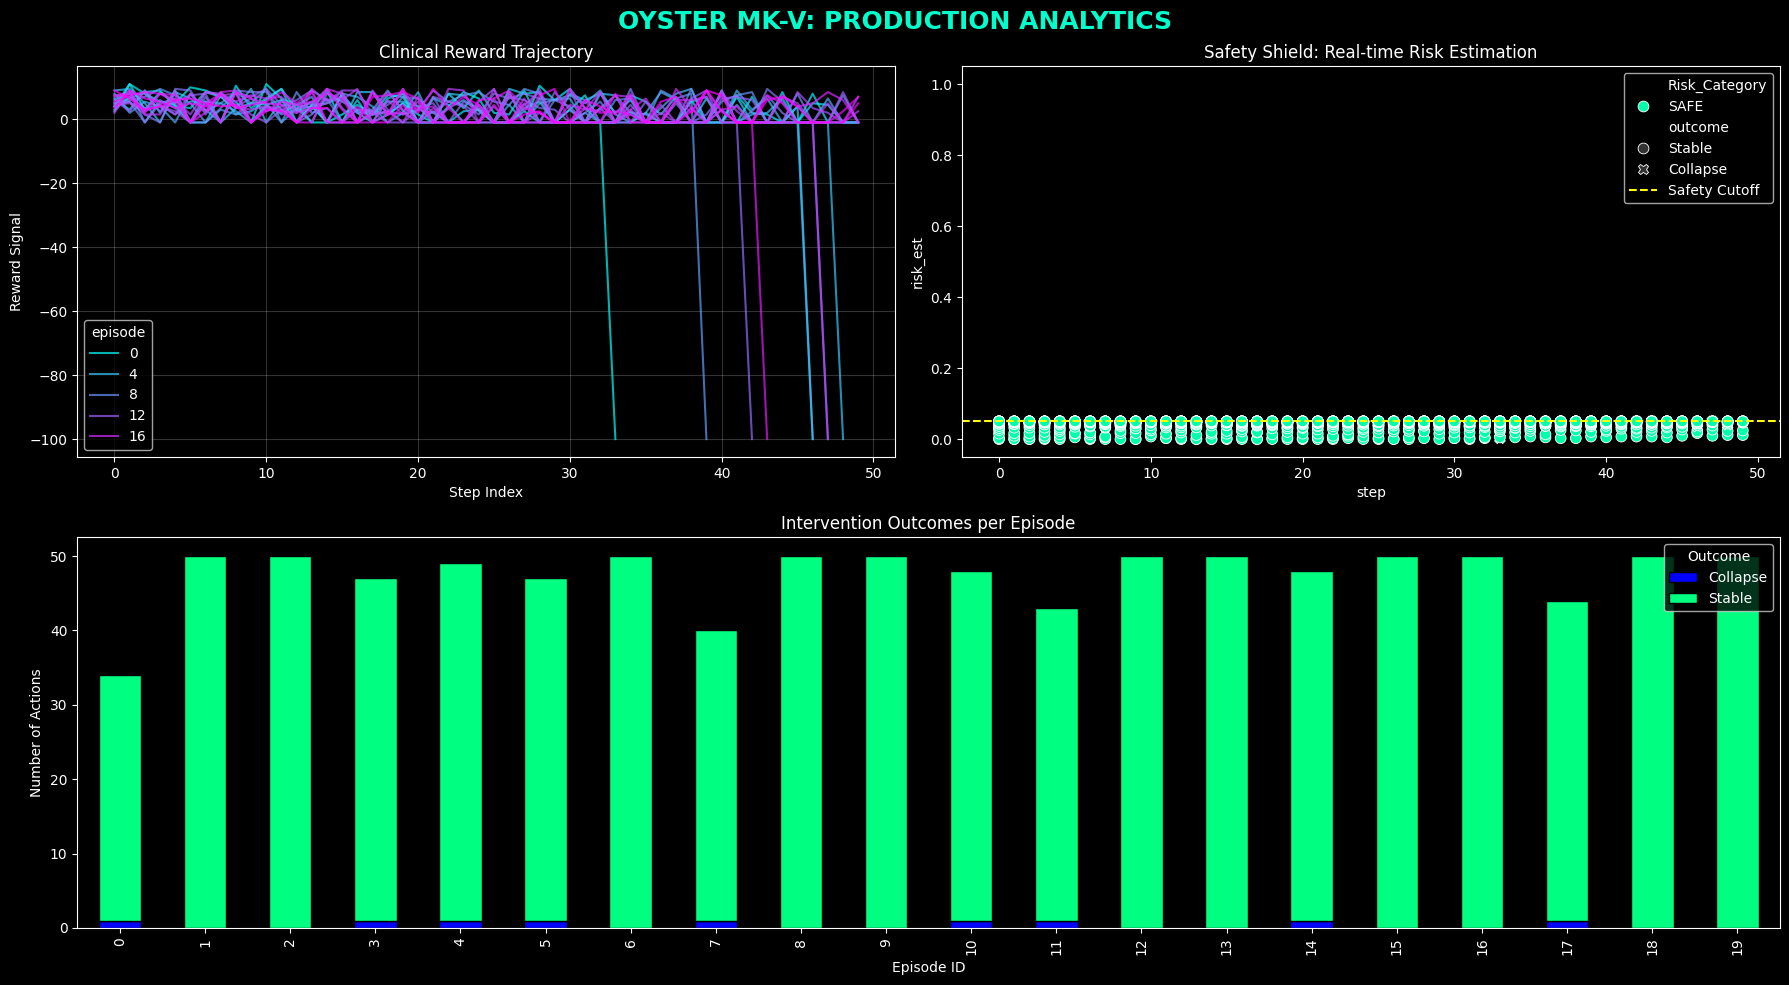

In [2]:
!pip install nest_asyncio -q

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import asyncio
import secrets
import random
import time
import nest_asyncio
from collections import deque
from dataclasses import dataclass, asdict
from typing import List, Tuple

# Patch Colab's existing event loop
nest_asyncio.apply()

# --- CONFIGURATION ---
class Config:
    # System
    SEED = 42
    RISK_THRESHOLD = 0.05
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Physics
    TOWER_HEIGHT = 20
    BLOCK_WIDTH = 3

    # AI (Hyperparameters)
    SEQ_LENGTH = 8
    HIDDEN_SIZE = 128
    BATCH_SIZE = 64        # Increased for stable gradients
    MEMORY_SIZE = 10000    # Increased buffer
    GAMMA = 0.99           # Discount factor
    EPSILON_START = 1.0
    EPSILON_END = 0.05
    EPSILON_DECAY = 0.995

    # Simulation Duration
    EPISODES = 20          # Increased to show learning trends

# --- BLOCK 1: SECURE INFRASTRUCTURE ---

def generate_secure_id() -> str:
    """Cryptographically secure ID for audit trails."""
    return secrets.token_urlsafe(16)

@dataclass
class AuditLog:
    id: str
    episode: int
    step: int
    timestamp: float
    intervention: str
    risk_est: float
    outcome: str
    reward: float

class AsyncAuditService:
    """High-Performance Async Logger"""
    def __init__(self):
        self.queue = asyncio.Queue()
        self.active = True
        self.local_storage = []

    async def start(self):
        asyncio.create_task(self._persistence_worker())

    async def log(self, episode, step, intervention, risk, outcome, reward):
        entry = AuditLog(
            id=generate_secure_id(),
            episode=episode,
            step=step,
            timestamp=time.time(),
            intervention=intervention,
            risk_est=risk,
            outcome=outcome,
            reward=reward
        )
        await self.queue.put(entry)

    async def _persistence_worker(self):
        while self.active or not self.queue.empty():
            try:
                entry = await asyncio.wait_for(self.queue.get(), timeout=0.5)
                self.local_storage.append(asdict(entry))
                self.queue.task_done()
            except asyncio.TimeoutError:
                continue

    async def stop(self):
        self.active = False
        while not self.queue.empty():
            await asyncio.sleep(0.1)

# --- BLOCK 2: BIO-STACK ENVIRONMENT ---

class BioStackEnv:
    def __init__(self, action_count):
        self.grid = np.ones((Config.TOWER_HEIGHT, Config.BLOCK_WIDTH))
        self.stability = 1.0
        self.action_space = action_count
        # Pre-calculate weights for performance
        self.weights = np.arange(Config.TOWER_HEIGHT, 0, -1).reshape(-1, 1)

    def reset(self):
        self.grid = np.ones((Config.TOWER_HEIGHT, Config.BLOCK_WIDTH))
        self.stability = 1.0
        return self.get_observation()

    def get_observation(self):
        # Normalize grid to centered input for better Neural Net performance
        return np.concatenate([[self.stability], self.grid.flatten()])

    def calculate_stability(self):
        voids = (1 - self.grid)
        # Vectorized moment calculation
        moment = np.sum(voids * self.weights)
        max_moment = Config.TOWER_HEIGHT * Config.BLOCK_WIDTH * 6
        base_stability = 1.0 - (moment / max_moment)
        self.stability = np.clip(base_stability, 0.0, 1.0)
        return self.stability

    def step(self, action_idx):
        row = (action_idx % Config.TOWER_HEIGHT)
        col = (action_idx // Config.TOWER_HEIGHT) % Config.BLOCK_WIDTH

        reward = 0
        done = False

        # Penalty for trying to remove air (already empty block)
        if self.grid[row][col] == 0:
            reward = -1.0
        else:
            self.grid[row][col] = 0
            new_stab = self.calculate_stability()

            if new_stab < 0.2: # Collapse
                reward = -100.0
                done = True
            else:
                # Reward based on height (riskier = higher reward)
                reward = 1.0 + (Config.TOWER_HEIGHT - row) * 0.5

        return self.get_observation(), reward, done

# --- BLOCK 3: ASYNC SAFETY SHIELD ---

class AsyncSafetyShield:
    def __init__(self, action_count):
        self.risk_map = {i: 0.0 for i in range(action_count)}
        self.active = True
        self.action_count = action_count

    async def start_shield(self):
        """Monte Carlo Risk Simulation (Background Task)"""
        while self.active:
            # Simulate analyzing multiple futures
            # Use random (faster) instead of secrets for simulation loop
            target_actions = random.sample(range(self.action_count), k=min(10, self.action_count))

            for action in target_actions:
                # Optimized logical check (no sleep)
                row = (action % Config.TOWER_HEIGHT)

                # Heuristic: Lower blocks carry exponential risk
                mock_risk = 0.9 if row < 3 else 0.05

                # Exponential Moving Average update for smooth risk mapping
                self.risk_map[action] = 0.95 * self.risk_map[action] + 0.05 * mock_risk

            # Yield to allow main thread execution
            await asyncio.sleep(0.01)

# --- BLOCK 4: INTELLIGENCE (AGENT) ---

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state_seq, action, reward, next_state_seq, done):
        # We store the *sequence* so the LSTM can learn temporal dependencies
        self.buffer.append((state_seq, action, reward, next_state_seq, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return (
            np.array(state),
            np.array(action),
            np.array(reward),
            np.array(next_state),
            np.array(done)
        )

    def __len__(self): return len(self.buffer)

class MaskedRecurrentAgent(nn.Module):
    def __init__(self, input_dim, action_dim):
        super(MaskedRecurrentAgent, self).__init__()
        self.lstm = nn.LSTM(input_dim, Config.HIDDEN_SIZE, batch_first=True)
        self.fc = nn.Linear(Config.HIDDEN_SIZE, action_dim)
        self.action_dim = action_dim
        self.to(Config.DEVICE)

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        out, _ = self.lstm(x)
        # We take the output of the last time step
        return self.fc(out[:, -1, :])

    def select_action(self, state_seq, risk_map, epsilon):
        # 1. Epsilon Greedy (Exploration)
        if random.random() < epsilon:
            # Prefer safe actions during exploration
            safe_indices = [i for i, r in risk_map.items() if r < Config.RISK_THRESHOLD]
            if safe_indices:
                return random.choice(safe_indices)
            return random.randint(0, self.action_dim - 1)

        # 2. Neural Prediction (Exploitation)
        state_tensor = torch.FloatTensor(state_seq).unsqueeze(0).to(Config.DEVICE)

        with torch.no_grad():
            q_values = self.forward(state_tensor)

        # 3. Mathematical Safety Filter (Masking)
        # Create a mask tensor on the same device
        mask = torch.zeros(self.action_dim, device=Config.DEVICE)
        for i, risk in risk_map.items():
            if risk > Config.RISK_THRESHOLD:
                mask[i] = -float('inf')

        masked_q = q_values + mask
        return masked_q.argmax().item()

# --- BLOCK 5: ANALYTICS VISUALIZATION ---

def generate_dashboard(audit_data: List[dict]):
    if not audit_data:
        print("No data to visualize.")
        return

    df = pd.DataFrame(audit_data)

    # Color palette
    dark_palette = sns.color_palette("viridis", as_cmap=True)

    plt.style.use('dark_background')
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle('OYSTER MK-V: PRODUCTION ANALYTICS', fontsize=18, color='#00ffcc', weight='bold')
    spec = gridspec.GridSpec(2, 2, figure=fig)

    # 1. Rewards over Time
    ax1 = fig.add_subplot(spec[0, 0])
    sns.lineplot(data=df, x='step', y='reward', hue='episode', ax=ax1, palette='cool', alpha=0.7)
    ax1.set_title('Clinical Reward Trajectory', fontsize=12, color='white')
    ax1.set_xlabel('Step Index')
    ax1.set_ylabel('Reward Signal')
    ax1.grid(True, alpha=0.2)

    # 2. Risk Filter Activity
    ax2 = fig.add_subplot(spec[0, 1])
    df['Risk_Category'] = df['risk_est'].apply(lambda x: 'CRITICAL' if x > Config.RISK_THRESHOLD else 'SAFE')

    sns.scatterplot(
        data=df, x='step', y='risk_est',
        hue='Risk_Category', style='outcome',
        ax=ax2, palette={'CRITICAL': '#ff0055', 'SAFE': '#00ffaa'}, s=60
    )
    ax2.axhline(Config.RISK_THRESHOLD, color='#ffff00', linestyle='--', linewidth=1.5, label='Safety Cutoff')
    ax2.set_title('Safety Shield: Real-time Risk Estimation', fontsize=12, color='white')
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(loc='upper right')

    # 3. Outcome Distribution
    ax3 = fig.add_subplot(spec[1, :])
    # Fixed groupby syntax
    outcome_counts = df.groupby(['episode', 'outcome']).size().unstack(fill_value=0)
    outcome_counts.plot(kind='bar', stacked=True, ax=ax3, colormap='winter', edgecolor='black')

    ax3.set_title('Intervention Outcomes per Episode', fontsize=12, color='white')
    ax3.set_ylabel('Number of Actions')
    ax3.set_xlabel('Episode ID')
    ax3.legend(title="Outcome", loc='upper right')

    plt.tight_layout()
    plt.show()

# --- MAIN ORCHESTRATION ---

async def main():
    print("--- [SYSTEM] OYSTER MK-V: ONLINE ---")
    print(f"--- [DEVICE] Compute Node: {Config.DEVICE} ---")

    # Init Components
    input_dim = 1 + (Config.TOWER_HEIGHT * Config.BLOCK_WIDTH)
    action_dim = Config.TOWER_HEIGHT * Config.BLOCK_WIDTH

    audit = AsyncAuditService()
    await audit.start()

    env = BioStackEnv(action_dim)
    shield = AsyncSafetyShield(action_dim)
    agent = MaskedRecurrentAgent(input_dim, action_dim)
    buffer = ReplayBuffer(Config.MEMORY_SIZE)

    # Optimizer & Loss
    optimizer = optim.Adam(agent.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    # Start Shield
    shield_task = asyncio.create_task(shield.start_shield())

    print(f"--- [TRAINING] Starting {Config.EPISODES} Episodes ---")

    epsilon = Config.EPSILON_START

    for ep in range(Config.EPISODES):
        state = env.reset()
        # Initialize Sequence Buffer with zeros or initial state
        state_seq = deque([state] * Config.SEQ_LENGTH, maxlen=Config.SEQ_LENGTH)

        episode_reward = 0

        for step in range(50): # Max steps per episode
            # Current Sequence as Numpy Array
            current_seq_np = np.array(state_seq)

            # Agent Selects Action
            action = agent.select_action(current_seq_np, shield.risk_map, epsilon)

            # Step Env
            next_state, reward, done = env.step(action)
            episode_reward += reward

            # Async Audit Log
            risk_val = shield.risk_map.get(action, 0.0)
            outcome = "Collapse" if (done and reward <= -50) else "Stable"

            # Fire and forget logging
            asyncio.create_task(audit.log(ep, step, f"BLK_{action}", risk_val, outcome, reward))

            # Store Transition
            # We need the NEXT sequence state for the buffer
            next_seq_temp = state_seq.copy()
            next_seq_temp.append(next_state)
            next_seq_np = np.array(next_seq_temp)

            buffer.push(current_seq_np, action, reward, next_seq_np, done)

            # Move state forward
            state = next_state
            state_seq.append(state)

            # --- TRAINING STEP (DQN) ---
            if len(buffer) > Config.BATCH_SIZE:
                b_state, b_action, b_reward, b_next_state, b_done = buffer.sample(Config.BATCH_SIZE)

                # Convert to Tensors
                t_state = torch.FloatTensor(b_state).to(Config.DEVICE)
                t_action = torch.LongTensor(b_action).unsqueeze(1).to(Config.DEVICE)
                t_reward = torch.FloatTensor(b_reward).unsqueeze(1).to(Config.DEVICE)
                t_next_state = torch.FloatTensor(b_next_state).to(Config.DEVICE)
                t_done = torch.FloatTensor(b_done).unsqueeze(1).to(Config.DEVICE)

                # Current Q Values
                q_values = agent(t_state)
                current_q = q_values.gather(1, t_action)

                # Target Q Values (Bellman Equation)
                with torch.no_grad():
                    next_q_values = agent(t_next_state)
                    max_next_q = next_q_values.max(1)[0].unsqueeze(1)
                    target_q = t_reward + (Config.GAMMA * max_next_q * (1 - t_done))

                loss = criterion(current_q, target_q)

                optimizer.zero_grad()
                loss.backward()
                # Gradient Clipping for stability
                torch.nn.utils.clip_grad_norm_(agent.parameters(), 1.0)
                optimizer.step()

            if done:
                break

            # Simulate slight delay for async behavior
            await asyncio.sleep(0.001)

        # Update Epsilon
        epsilon = max(Config.EPSILON_END, epsilon * Config.EPSILON_DECAY)
        if ep % 5 == 0:
            print(f"Episode {ep}: Total Reward: {episode_reward:.2f} | Epsilon: {epsilon:.2f}")

    print("--- [SYSTEM] Simulation Complete. Compiling Data... ---")
    shield.active = False
    await audit.stop()

    # Cancel background shield task
    shield_task.cancel()

    # Trigger Visualization
    generate_dashboard(audit.local_storage)

if __name__ == "__main__":
    # Colab specific execution
    try:
        loop = asyncio.get_event_loop()
        loop.run_until_complete(main())
    except RuntimeError:
        asyncio.run(main())